In [91]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from pydantic import BaseModel,Field

In [92]:
import os
import requests
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

In [93]:
load_dotenv(override=True)

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

llm = ChatOpenAI(
    model_name="gpt-4o-mini",
    temperature=0,
    openai_api_key=OPENAI_API_KEY)

In [94]:
class SentimentSchema(BaseModel):
    sentiment:Literal["positive","negative"] = Field(description='Review Sentiment either positive or negative')

structured_sentiment_llm = llm.with_structured_output(SentimentSchema)


In [95]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX","Performance","Bug","Support","Other"] = Field(description="The category of the issue mentioned in the review")
    tone: Literal["angry","frustrated","disappointed","clam"] = Field(description="The emotional tone expressed by user")
    urgency: Literal["low","medium","high"] = Field(description="How urgent or cititical the issue appears to be")

structured_diagnosis_llm = llm.with_structured_output(DiagnosisSchema)


In [96]:
class ReviewState(TypedDict):
    review: str    

    sentiment: Literal["positive","negative"]
    diagnosis: dict
    response: str
    

In [97]:
def find_sentiment(state: ReviewState) -> dict:
    """Find the sentiment of the review."""
    review = state["review"]
    prompt = f"For the following review find out the sentiment \n {review}"
    sentiment = structured_sentiment_llm.invoke(prompt).sentiment
    return {"sentiment":sentiment}

In [98]:
def positive_response(state: ReviewState) -> dict:
    """Response for positive review."""
    review = state["review"]
    prompt = f"""Write a wram thank you message in response to this review: 
    \n {review} 
    \n
    
    Also, kindly ask user to leave a feedback on our website."""
    response = llm.invoke(prompt).content
    return {"response":response}

In [99]:
def run_diagnosis(state: ReviewState) -> dict:
    """Run the diagnosis on the review."""
    review = state["review"]
    prompt = f"""Diagnosis this negative review: 
    \n {review}
    \n 
    Return the issue_type, tone and urgency
    """
    diagnosis = structured_diagnosis_llm.invoke(prompt)
    return {"diagnosis":diagnosis.model_dump()}

In [100]:
def negative_response(state: ReviewState) -> dict:
    """Response for negative review."""
    review = state["review"]
    sentiment = state["sentiment"]
    diagnosis = state["diagnosis"]
    prompt = f"""You are support assistant.
    The user had a '{diagnosis['issue_type']}' issue, 
    sounded  '{diagnosis['tone']}' and
    marked urgency as '{diagnosis['urgency']}'

    Write an empathetic, helpful resolution message.
    """

    response = llm.invoke(prompt).content
    return {"response":response}

In [112]:
def check_condition(state:ReviewState)-> Literal["positive_response","run_diagnosis"]:
    # Mirros the conditional routing based on the descriminant in the original
    if state["sentiment"] == "positive":
        return "positive_response"
    else:
        return "run_diagnosis"
    

In [114]:
graph = StateGraph(ReviewState)

In [115]:
graph.add_node("find_sentiment",find_sentiment)
graph.add_node("run_diagnosis",run_diagnosis)
graph.add_node("positive_response",positive_response)
graph.add_node("negative_response",negative_response)


In [116]:
graph.add_edge(START,"find_sentiment")
graph.add_conditional_edges("find_sentiment",check_condition)
graph.add_edge("positive_response",END)
graph.add_edge("run_diagnosis","negative_response")
graph.add_edge("negative_response",END)


In [117]:
workflow = graph.compile()

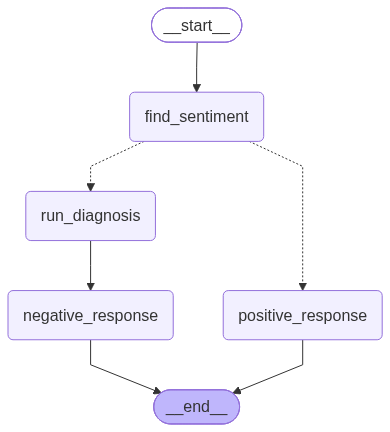

In [106]:
workflow

In [118]:
initial_state = {
    "review":"Application works smoothly on my phone and design is good",
}

In [108]:
initial_state = {
    "review":"Application fails whenever i try to open in on my desktop mozilla browser, its fails always.",
}

In [119]:
workflow.invoke(initial_state)

{'review': 'Application works smoothly on my phone and design is good',
 'sentiment': 'positive',
 'response': "Subject: Thank You for Your Kind Review!\n\nDear [User's Name],\n\nThank you so much for your wonderful review! We're thrilled to hear that our application is working smoothly on your phone and that you appreciate the design. Your feedback means a lot to us!\n\nIf you have a moment, we would greatly appreciate it if you could share your thoughts on our website as well. Your insights help us continue to improve and provide the best experience for our users.\n\nThank you once again for your support!\n\nWarm regards,  \n[Your Name]  \n[Your Position]  \n[Your Company]  "}